In [18]:
# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
!pip install torchinfo
from torchinfo import summary
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt


In [19]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

In [20]:
# 데이터셋 로드하고 기본 정보 확인
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

Image shape: torch.Size([3, 32, 32])
Label: 6
Number of classes: 10


In [21]:
# 이미지 정규화 
transform = transforms.Compose([
    transforms.ToTensor()  # uint8 → float32 변환 + 0~1 정규화
])

In [14]:
# 1. 라이브러리가 설치되어 있지 않다면 설치 (주피터 셀에서 바로 설치하는 명령어)
!pip install torchsummary

# 2. 설치된 라이브러리에서 summary 함수 가져오기
from torchsummary import summary

In [15]:
import torch
import torch.nn as nn


# 1. ResNet-34: Basic Block

class BasicBlock(nn.Module):
    expansion = 1  # 출력 채널 배수

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        
        # conv1: 3x3
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        # conv2: 3x3
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 스킵 커넥션을 위한 다운샘플링 (크기나 채널이 바뀔 때 맞추는 용도)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion))

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity  # 잔차 더하기 (F(x) + x)
        out = self.relu(out)
        return out



# 2. ResNet-50:Bottleneck Block

class BottleneckBlock(nn.Module):
    expansion = 4  # 최종 출력 채널은 중간 채널의 4배가 됨

    def __init__(self, in_channels, out_channels, stride=1):
        super(BottleneckBlock, self).__init__()
        
        # 1x1 Conv: 채널 압축
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # 3x3 Conv: 특징 추출 (여기서 stride 적용)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 1x1 Conv: 채널 확장 (out_channels * 4)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, stride=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        
        # 스킵 커넥션을 위한 다운샘플링
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion))
        

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        out += identity  
        out = self.relu(out)
        return out



# 3. 통합 마스터 생성 함수: build_resnet()

def build_resnet(block_type, num_blocks_list, num_classes=1000):
    layers = []
    
    # 1. Root 레이어 (표의 맨 위 conv1 공통 구간), 입력 이미지 채널 3 -> 64 확장
    layers.append(nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False))
    layers.append(nn.BatchNorm2d(64))
    layers.append(nn.ReLU(inplace=True))
    layers.append(nn.MaxPool2d(kernel_size=3, stride=2, padding=1)) 

    # 각 스테이지의 기본 중간 채널 수 설정
    stage_channels = [64, 128, 256, 512]
    in_channels = 64  # 현재 흘러가는 텐서의 실제 채널 수 변수

    # 2. ResNet 스테이지 순차 생성 (conv2_x ~ conv5_x)
    for i, num_blocks in enumerate(num_blocks_list):
        out_channels = stage_channels[i]
        
        # 각 스테이지의 첫 번째 블록에서만 해상도를 반으로 줄임 (conv2_x 제외)
        stride = 1 if i == 0 else 2
        
        # 스테이지의 첫 번째 블록 생성
        layers.append(block_type(in_channels, out_channels, stride=stride))
        in_channels = out_channels * block_type.expansion
        
        # 스테이지의 나머지 블록들 반복 생성
        for _ in range(1, num_blocks):
            layers.append(block_type(in_channels, out_channels, stride=1))

    # 3. 고정된 출력층 (AvgPool + FC 분류기)
    layers.append(nn.AdaptiveAvgPool2d((1, 1))) # 7x7 해상도를 1x1로 압축
    layers.append(nn.Flatten())
    layers.append(nn.Linear(in_channels, num_classes))

    # 하나의 거대한 순차 모델로 묶어서 반환
    return nn.Sequential(*layers)

In [17]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. ResNet-34 생성
resnet34 = build_resnet(block_type=BasicBlock, num_blocks_list=[3, 4, 6, 3], num_classes=1000)
resnet34 = resnet34.to(device)
summary(resnet34, input_size=(3, 224, 224))
        
# 2. ResNet-50 생성
resnet50 = build_resnet(block_type=BottleneckBlock, num_blocks_list=[3, 4, 6, 3], num_classes=1000)
resnet50 = resnet50.to(device)
summary(resnet50, input_size=(3, 224, 224))



----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [30]:
## Oxford-IIIT Pet 데이터 로드

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 1. 이미지 전처리(Transform)모델 입력 규격에 맞게 크기를 조정하고 텐서로 변환
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),       # ResNet 등 표준 모델 입력 크기(224x224)로 맞춤
    transforms.RandomHorizontalFlip(),   # 데이터 증강 (학습용)
    transforms.ToTensor(),               # 0~1 사이의 텐서로 변환
    transforms.Normalize(                # ImageNet 데이터셋 기준 정규화
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. 데이터셋 다운로드 및 불러오기 : target_types='category'는 37개 품종 
train_dataset = datasets.OxfordIIITPet(
    root='./data',           # 데이터가 다운로드될 저장 경로
    split='trainval',        # 학습 및 검증용 split ('trainval' 또는 'test')
    target_types='category', # 라벨 종류 ('category', 'segmentation' 중 선택 가능)
    transform=train_transform,
    download=True            # 경로에 데이터가 없으면 자동 다운로드
)

test_dataset = datasets.OxfordIIITPet(
    root='./data',
    split='test',
    target_types='category',
    transform=val_transform,
    download=True
)

# 3. 데이터 로더 배치 구성: 학습용은 무작위로 섞어주고(shuffle=True), 검증용은 순서대로 평가
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# 4. 데이터 정상 로드 확인용 출력
print(f"학습 데이터 개수: {len(train_dataset)}")
print(f"테스트 데이터 개수: {len(test_dataset)}")
print(f"총 클래스(품종) 개수: {len(train_dataset.classes)}")

학습 데이터 개수: 3680
테스트 데이터 개수: 3669
총 클래스(품종) 개수: 37


In [31]:
## Plain / Residual 겸용 블록 및 모델 수정

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm


# 1. 스위치가 추가된 Bottleneck Block (ResNet-50용)

class BottleneckBlockWithSwitch(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, use_residual=True):
        super(BottleneckBlockWithSwitch, self).__init__()
        self.use_residual = use_residual
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        # use_residual이 True일 때만 Skip Connection을 더해줌
        if self.use_residual:
            out += identity
            
        out = self.relu(out)
        return out


# 2. 통합 모델 생성 함수

def build_custom_resnet(block_type, num_blocks_list, use_residual=True, num_classes=37):
    """ use_residual=False로 지정하면 오리지널 Plain-50 모델이 됨
        OxfordPet 분류를 위해 num_classes는 37로 지정"""
    
    layers = []
    layers.append(nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False))
    layers.append(nn.BatchNorm2d(64))
    layers.append(nn.ReLU(inplace=True))
    layers.append(nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

    stage_channels = [64, 128, 256, 512]
    in_channels = 64

    for i, num_blocks in enumerate(num_blocks_list):
        out_channels = stage_channels[i]
        stride = 1 if i == 0 else 2
        
        # 블록 생성 시 use_residual 옵션을 주입합니다.
        layers.append(block_type(in_channels, out_channels, stride=stride, use_residual=use_residual))
        in_channels = out_channels * block_type.expansion
        
        for _ in range(1, num_blocks):
            layers.append(block_type(in_channels, out_channels, stride=1, use_residual=use_residual))

    layers.append(nn.AdaptiveAvgPool2d((1, 1)))
    layers.append(nn.Flatten())
    layers.append(nn.Linear(in_channels, num_classes))

    return nn.Sequential(*layers)

In [32]:
## Train 및 Validation 표준 루프 함수 정의

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    val_loss = running_loss / total
    val_acc = (correct / total) * 100
    return val_loss, val_acc

In [33]:
## Plain 50 vs ResNet 50 비교 

# 하이퍼파라미터 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 10  # 실습 목적에 맞춰 에포크 조정 가능
BATCH_SIZE = 32
LR = 0.001

# 두 결과를 저장할 딕셔너리
history = {
    'plain_val_acc': [],
    'residual_val_acc': []}


# Plain-50 모델학습

print("=== Plain-50 모델 학습 시작 ===")
plain_50 = build_custom_resnet(BottleneckBlockWithSwitch, [3, 4, 6, 3], use_residual=False).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(plain_50.parameters(), lr=LR)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(plain_50, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(plain_50, test_loader, criterion, device)
    history['plain_val_acc'].append(val_acc)
    print(f"[Epoch {epoch+1}/{EPOCHS}] Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")


# ResNet-50 모델학습

print("\n=== ResNet-50 모델 학습 시작 ===")
resnet_50 = build_custom_resnet(BottleneckBlockWithSwitch, [3, 4, 6, 3], use_residual=True).to(device)
optimizer = optim.Adam(resnet_50.parameters(), lr=LR)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(resnet_50, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(resnet_50, test_loader, criterion, device)
    history['residual_val_acc'].append(val_acc)
    print(f"[Epoch {epoch+1}/{EPOCHS}] Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

=== Plain-50 모델 학습 시작 ===
[Epoch 1/10] Train Acc: 3.51% | Val Acc: 3.13%
[Epoch 2/10] Train Acc: 4.18% | Val Acc: 4.52%
[Epoch 3/10] Train Acc: 4.89% | Val Acc: 5.61%
[Epoch 4/10] Train Acc: 5.11% | Val Acc: 5.23%
[Epoch 5/10] Train Acc: 5.49% | Val Acc: 4.82%
[Epoch 6/10] Train Acc: 5.14% | Val Acc: 3.38%
[Epoch 7/10] Train Acc: 3.72% | Val Acc: 3.65%
[Epoch 8/10] Train Acc: 3.97% | Val Acc: 1.99%
[Epoch 9/10] Train Acc: 4.78% | Val Acc: 3.60%
[Epoch 10/10] Train Acc: 4.35% | Val Acc: 4.69%

=== ResNet-50 모델 학습 시작 ===
[Epoch 1/10] Train Acc: 3.80% | Val Acc: 4.96%
[Epoch 2/10] Train Acc: 5.35% | Val Acc: 5.40%
[Epoch 3/10] Train Acc: 6.20% | Val Acc: 6.46%
[Epoch 4/10] Train Acc: 7.80% | Val Acc: 8.69%
[Epoch 5/10] Train Acc: 9.67% | Val Acc: 8.83%
[Epoch 6/10] Train Acc: 10.68% | Val Acc: 11.39%
[Epoch 7/10] Train Acc: 12.50% | Val Acc: 11.28%
[Epoch 8/10] Train Acc: 13.51% | Val Acc: 11.69%
[Epoch 9/10] Train Acc: 14.76% | Val Acc: 13.46%
[Epoch 10/10] Train Acc: 15.24% | Val Acc: 1


=== Ablation Study 최종 결과표 ===
 Epoch  Plain-50 Val Acc (%)  ResNet-50 Val Acc (%)  Delta (%p)
     1              3.134369               4.960480    1.826111
     2              4.524394               5.396566    0.872172
     3              5.614609               6.459526    0.844917
     4              5.233034               8.694467    3.461434
     5              4.824203               8.830744    4.006541
     6              3.379667              11.392750    8.013083
     7              3.652221              11.283729    7.631507
     8              1.989643              11.692559    9.702916
     9              3.597711              13.464159    9.866449
    10              4.687926              12.673753    7.985827


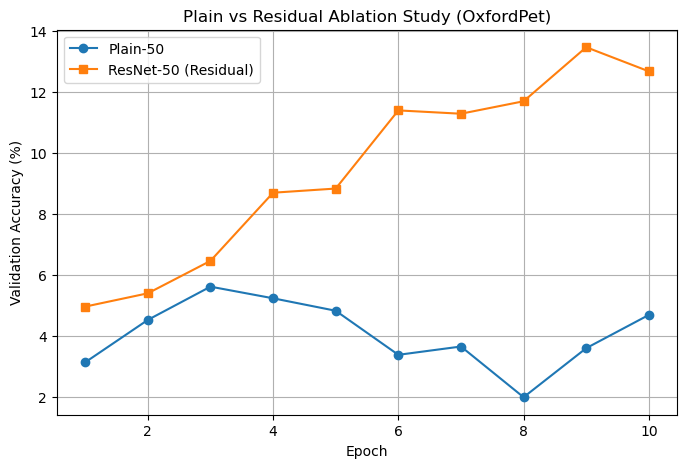

In [34]:
## 결과 비교표 출력 및 시각화 

import pandas as pd
import matplotlib.pyplot as plt

# 1. 판다스 데이터프레임으로 비교 결과표 생성
df_result = pd.DataFrame({
    'Epoch': range(1, EPOCHS + 1),
    'Plain-50 Val Acc (%)': history['plain_val_acc'],
    'ResNet-50 Val Acc (%)': history['residual_val_acc']
})
df_result['Delta (%p)'] = df_result['ResNet-50 Val Acc (%)'] - df_result['Plain-50 Val Acc (%)']

print("\n=== Ablation Study 최종 결과표 ===")
print(df_result.to_string(index=False))

# 2. 간단한 트렌드 그래프 시각화
plt.figure(figsize=(8, 5))
plt.plot(df_result['Epoch'], df_result['Plain-50 Val Acc (%)'], label='Plain-50', marker='o')
plt.plot(df_result['Epoch'], df_result['ResNet-50 Val Acc (%)'], label='ResNet-50 (Residual)', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Plain vs Residual Ablation Study (OxfordPet)')
plt.grid(True)
plt.legend()
plt.show()

In [35]:
from tqdm import tqdm  # 진행률 표시 라이브러리

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # dataloader 진행상황 시각화.
    pbar = tqdm(dataloader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # 현재 배치의 Loss와 정확도
        pbar.set_postfix(loss=loss.item(), acc=(correct/total)*100)
        
    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100
    return epoch_loss, epoch_acc

In [36]:
import torchvision.models as models

## 레벨 정확도를 보기 위한 전이학습 모델 함수
def get_pretrained_resnet50(num_classes=37):
    # ImageNet으로 이미 최고 수준 학습이 완료된 ResNet-50의 뼈대와 가중치를 그대로 가져옵니다.
  
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    
    # 원래 1000개 클래스용이었던 맨 마지막 예측 레이어(fc)를 
    # 우리 목적에 맞게 OxfordPet의 37개 클래스용 새 레이어로 교체
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    return model

device = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 5  
# 전이 학습은 성능이 워낙 빨라 5 에포크면 충분

# 모델 선언 및 GPU 이동
pretrained_resnet50 = get_pretrained_resnet50(num_classes=37).to(device)

# 기존에 쓰시던 Optimizer와 Criterion 그대로 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pretrained_resnet50.parameters(), lr=0.0001) # 조금 더 세밀하게 정돈하기 위해 lr은 살짝 낮춥니다.

# 학습 시작
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(pretrained_resnet50, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(pretrained_resnet50, test_loader, criterion, device)
    print(f"[Epoch {epoch+1}/{EPOCHS}] Pretrained Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]
Training: 100%|██████████| 115/115 [00:50<00:00,  2.29it/s, acc=65.6, loss=0.529]


[Epoch 1/5] Pretrained Train Acc: 65.57% | Val Acc: 89.62%


Training: 100%|██████████| 115/115 [00:51<00:00,  2.24it/s, acc=93.7, loss=0.237] 


[Epoch 2/5] Pretrained Train Acc: 93.67% | Val Acc: 90.84%


...

[Epoch 3/5] Pretrained Train Acc: 96.58% | Val Acc: 91.58%


Training: 100%|██████████| 115/115 [00:51<00:00,  2.22it/s, acc=98.5, loss=0.187] 


[Epoch 4/5] Pretrained Train Acc: 98.53% | Val Acc: 90.84%


Training: 100%|██████████| 115/115 [00:51<00:00,  2.23it/s, acc=98.9, loss=0.00812]


[Epoch 5/5] Pretrained Train Acc: 98.86% | Val Acc: 90.87%
